<a href="https://colab.research.google.com/github/Horeisan/Mushroom-Dataset-Analysis/blob/main/Mushroom_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Dataset Exploring

In [ ]:

import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

path = kagglehub.dataset_download("uciml/mushroom-classification")

df = pd.read_csv(os.path.join(path, 'mushrooms.csv'))

pd.set_option("display.max_columns", None)   #We can see all the features now

#Checking if we have any missing value
display(df.isnull().sum())

#Displaying dataset
display(df)

#Seeing object types
display(df.dtypes)

#Description
df.describe(include='all').T

Using Colab cache for faster access to the 'mushroom-classification' dataset.


,0
class,0
cap-shape,0
cap-surface,0
cap-color,0
bruises,0
odor,0
gill-attachment,0
gill-spacing,0
gill-size,0
gill-color,0


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,e,?,s,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,e,?,s,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,e,?,s,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,t,?,s,k,w,w,p,w,o,e,w,v,l


,0
class,object
cap-shape,object
cap-surface,object
cap-color,object
bruises,object
odor,object
gill-attachment,object
gill-spacing,object
gill-size,object
gill-color,object


,count,unique,top,freq
class,8124,2,e,4208
cap-shape,8124,6,x,3656
cap-surface,8124,4,y,3244
cap-color,8124,10,n,2284
bruises,8124,2,f,4748
odor,8124,9,n,3528
gill-attachment,8124,2,f,7914
gill-spacing,8124,2,c,6812
gill-size,8124,2,b,5612
gill-color,8124,12,b,1728


Deci am observat ca nu exista valori lipsa si ca toate featurile sunt categorice

###Adding new features

#Plotting Distributions

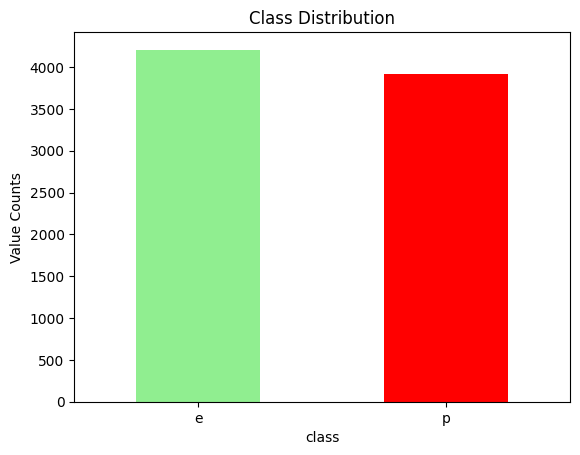

In [ ]:
x = df["class"].value_counts().plot(kind = 'bar', color = ["lightgreen","red"])
plt.title("Class Distribution")
x.set_xticklabels(df["class"].value_counts().index, rotation = 0)
plt.ylabel("Value Counts")
plt.show()

<Figure size 1000x600 with 0 Axes>

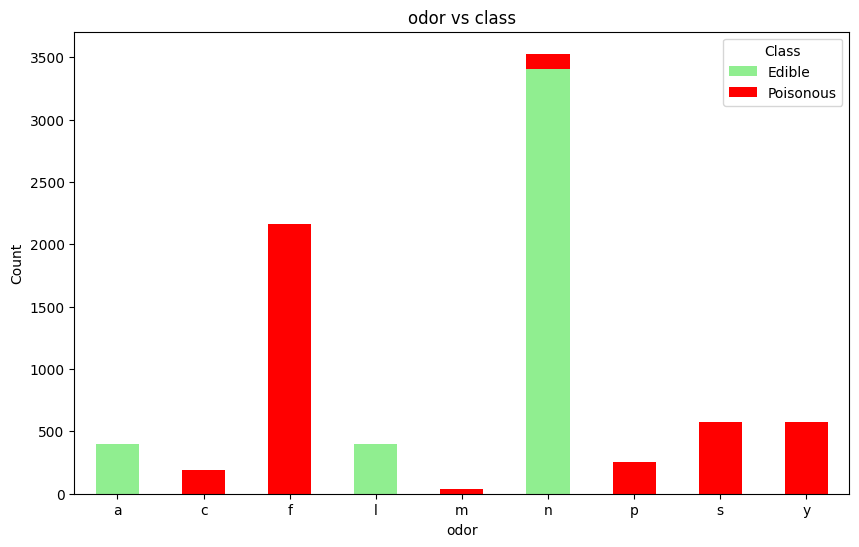

<Figure size 1000x600 with 0 Axes>

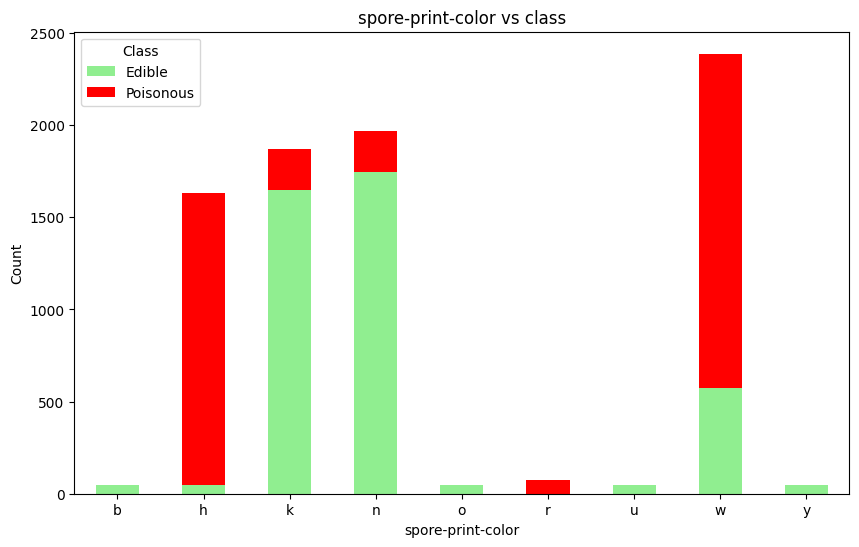

<Figure size 1000x600 with 0 Axes>

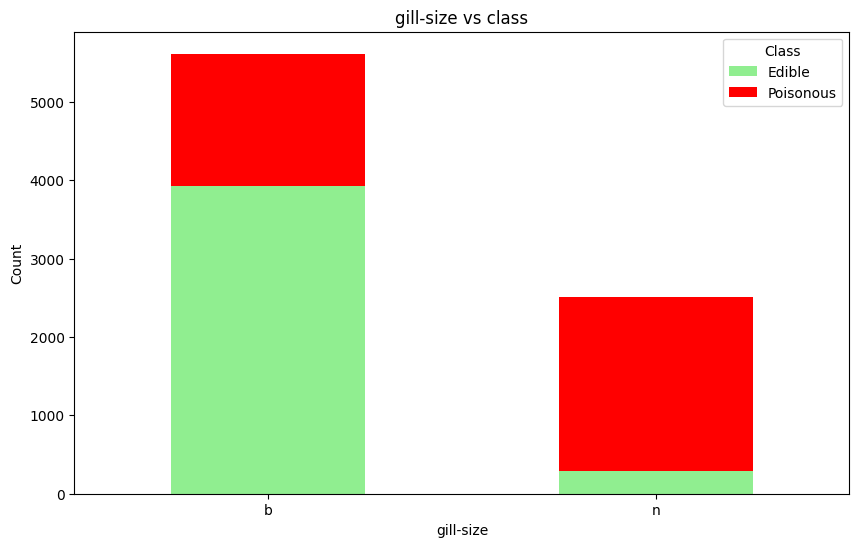

<Figure size 1000x600 with 0 Axes>

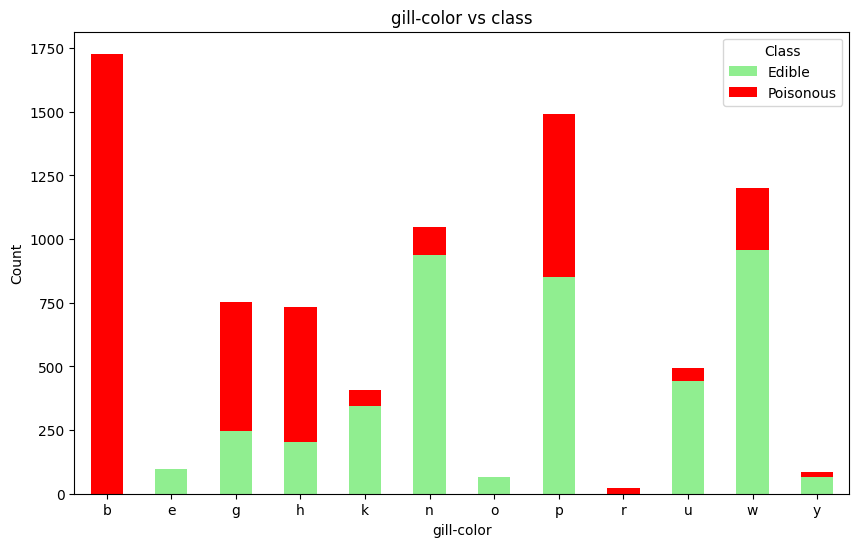

In [ ]:
features = ["odor", "spore-print-color", "gill-size", "gill-color"]

for col in features:
    plt.figure(figsize=(10,6))

    ctab = pd.crosstab(df[col], df["class"])

    ctab.plot(kind="bar", stacked=True, figsize=(10,6), color=["lightgreen","red"])

    plt.title(f"{col} vs class")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.legend(["Edible","Poisonous"], title="Class")
    plt.show()


#One Hot Encoding on the entire dataset

In [ ]:
df = pd.get_dummies(df,drop_first = True)





#Detecting the most important features

,0
odor_n,-0.785557
ring-type_p,-0.540469
bruises_t,-0.501530
stalk-surface-above-ring_s,-0.491314
stalk-surface-below-ring_s,-0.425444
...,...
spore-print-color_h,0.490229
gill-size_n,0.540024
stalk-surface-below-ring_k,0.573524
stalk-surface-above-ring_k,0.587658


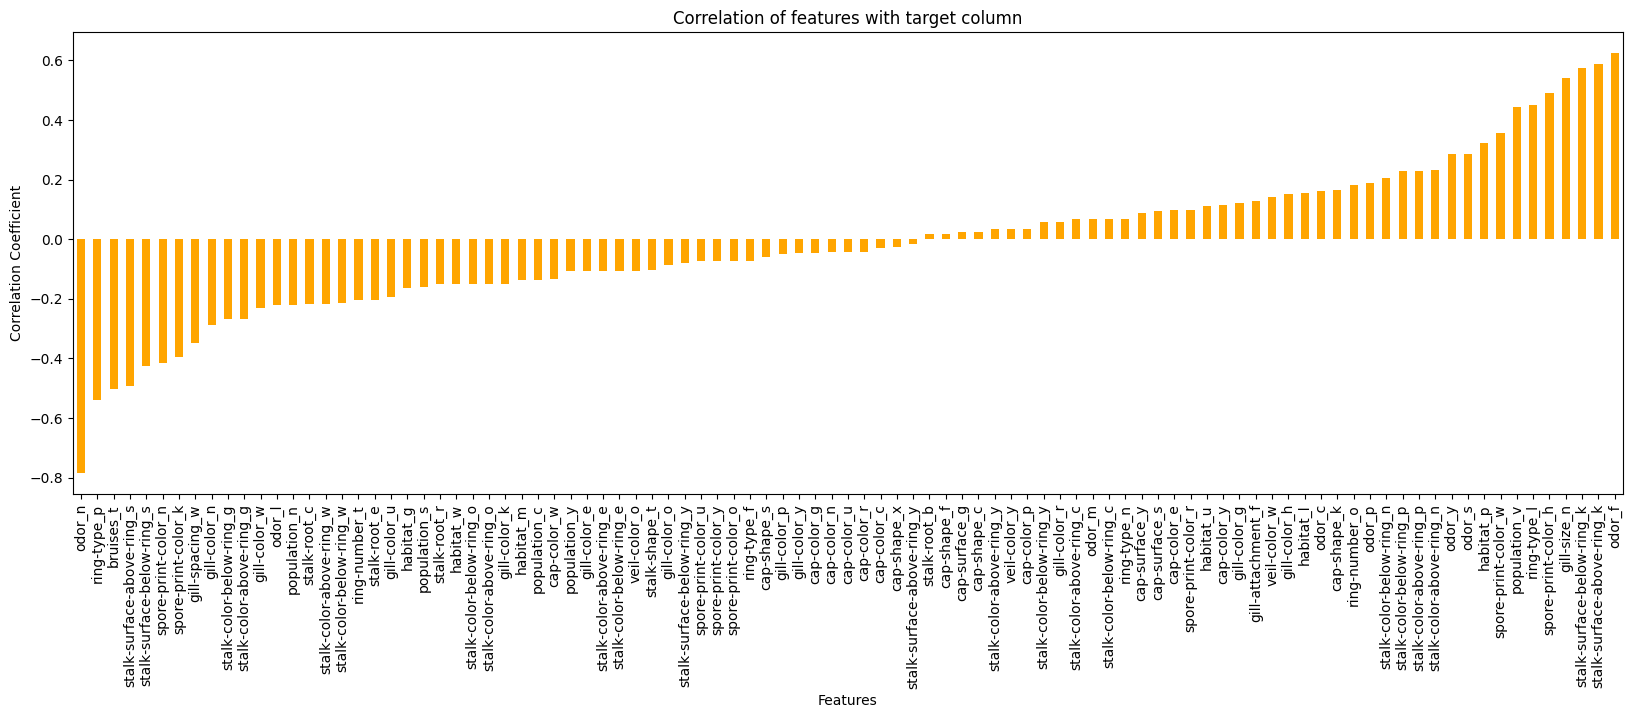

In [ ]:
corr_matrix = df.corr(method = 'pearson')
plt.figure(figsize=(20,6))

sorted_matrix = corr_matrix.unstack()["class_p"].sort_values()[:-1]
display(sorted_matrix)
sorted_matrix.plot(kind='bar',color = 'orange')

plt.title("Correlation of features with target column")
plt.xlabel("Features")
plt.ylabel("Correlation Coefficient")
plt.show()

#Creating pipeline

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression


def add_label_noise(df, target_col="class", noise_frac=0.1, random_state=None):

    rng = np.random.default_rng(random_state)
    n_flip = int(noise_frac * len(df))
    flip_idx = rng.choice(df.index, size=n_flip, replace=False)
    df.loc[flip_idx, target_col] = df.loc[flip_idx, target_col].map(
        lambda x: "e" if x == "p" else "p"
    )
    return df
def add_feature_noise(df, column, frac=0.1, seed=42):

    np.random.seed(seed)
    mask = np.random.rand(len(df)) < frac
    df.loc[mask, column] = np.random.choice(df[column].unique(), mask.sum())
    return df


path = kagglehub.dataset_download("uciml/mushroom-classification")
df = pd.read_csv(os.path.join(path, 'mushrooms.csv'))

df = add_label_noise(df, target_col="class", noise_frac=0.1, random_state=42)
df = add_feature_noise(df, column="odor", frac=0.3, seed=42)

y = df["class"]
x = df.drop(["class"], axis=1)



categorical_features = list(x.columns)


x_train,x_test,y_train,y_test = train_test_split(x,y,random_state = 42,test_size=0.2,stratify = y)

cat_transformer = Pipeline([
    ("onehot" ,OneHotEncoder(handle_unknown= 'ignore'))

])

preprocessor = ColumnTransformer([
           ("cat", cat_transformer, categorical_features)
])

pipe = Pipeline([
    ("preprocessor",preprocessor),
    ("classifier",LogisticRegression())
])


pipe.fit(x_train, y_train)

y_pred = pipe.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

Using Colab cache for faster access to the 'mushroom-classification' dataset.
Model Accuracy: 0.90


#Creating Confusion Matrix

In [ ]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report
def confusion_model(model,x_train,y_train,x_test,y_test,model_name):
  model.fit(x_train,y_train)
  y_pred = model.predict(x_test)


  print(f"Model name = {model_name}")
  cm = confusion_matrix(y_test,y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels = ['Edible','Poisonous'])
  disp.plot(cmap=plt.cm.Blues)


  print(classification_report(y_test, y_pred, target_names=["Edible","Poisonous"]))
  plt.show()

#Creating GridSearch For each algorithm

###Logistic Regression

Model name = Logistic Regression Before
              precision    recall  f1-score   support

      Edible       0.89      0.91      0.90       832
   Poisonous       0.90      0.89      0.89       793

    accuracy                           0.90      1625
   macro avg       0.90      0.90      0.90      1625
weighted avg       0.90      0.90      0.90      1625



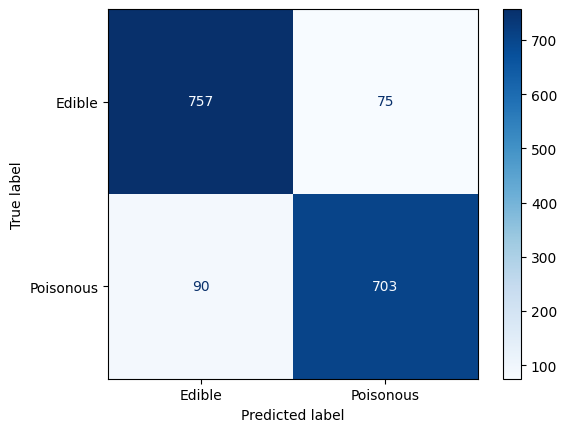

Best parameters found by Grid Search: {'classifier__C': 10, 'classifier__class_weight': None, 'classifier__max_iter': 1000, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Model name = Logistic Regression After
              precision    recall  f1-score   support

      Edible       0.89      0.91      0.90       832
   Poisonous       0.90      0.88      0.89       793

    accuracy                           0.90      1625
   macro avg       0.90      0.90      0.90      1625
weighted avg       0.90      0.90      0.90      1625



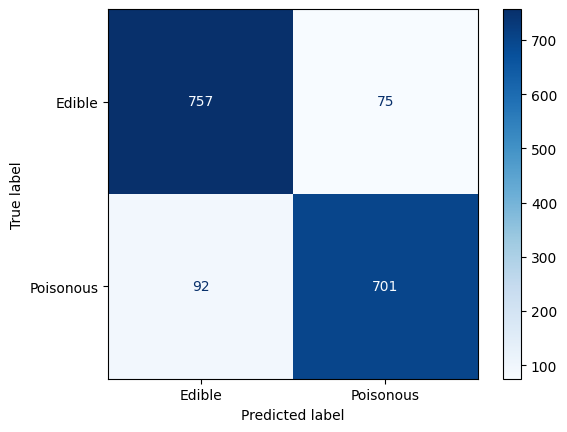

Cv score = [0.90930788 0.90952666 0.90107271 0.90161002 0.89155183]
 Mean score = 0.9026138178999646
 Std score = 0.006608299475129528

CV mean vs Test: 0.9026138178999646 vs 0.8937426210153483


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer,precision_score,recall_score,f1_score
from sklearn.model_selection import cross_val_score,StratifiedKFold


pipe = Pipeline([
    ("preprocessor",preprocessor),
    ("classifier",LogisticRegression(random_state = 42))
])


pipe.fit(x_train, y_train)
confusion_model(pipe,x_train,y_train,x_test,y_test,"Logistic Regression Before")


param_grid = {
    "classifier__penalty": ["l2"],  #am lasat un parametru pentru a rula codu mai repede ca deja am testat
    "classifier__C": [0.01, 0.1, 1,10],
    "classifier__solver": ["liblinear", "saga"],
    "classifier__max_iter": [1000,5000,10000],
    "classifier__class_weight": [None, "balanced"]
}
scorer = make_scorer(f1_score, pos_label="e")
cv_fold = StratifiedKFold(n_splits=5, shuffle = True, random_state = 42)


grid_search = GridSearchCV(estimator = pipe,param_grid = param_grid, cv = cv_fold, scoring = scorer)
grid_search.fit(x_train,y_train)

print(f"Best parameters found by Grid Search: {grid_search.best_params_}")

best_params = grid_search.best_params_
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        penalty = best_params['classifier__penalty'],
        C = best_params['classifier__C'],
        solver = best_params['classifier__solver'],
        max_iter = best_params['classifier__max_iter'],
        class_weight = best_params['classifier__class_weight'],
        random_state = 42
    ))
])

confusion_model(pipeline_lr,x_train,y_train,x_test,y_test,"Logistic Regression After")

cross_val_score = cross_val_score(pipeline_lr,x,y,scoring = scorer, cv = cv_fold)


print(f"Cv score = {cross_val_score}\n Mean score = {np.mean(cross_val_score)}\n Std score = {np.std(cross_val_score)}\n")
y_prec = precision_score(y_test,y_pred,pos_label = 'e')
print("CV mean vs Test:", np.mean(cross_val_score), "vs", y_prec)




#Roc curve

AUC: 0.9032


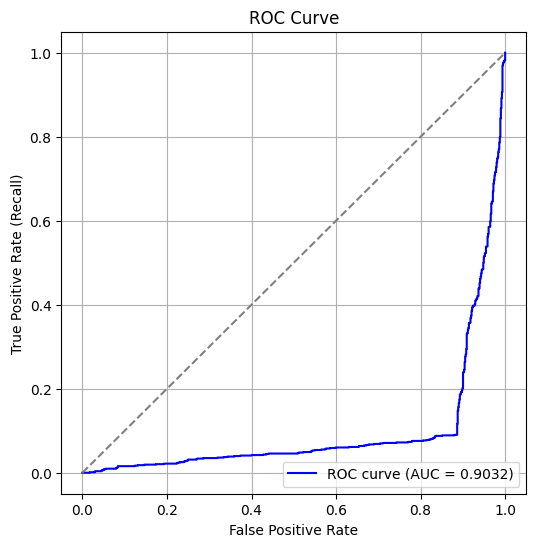

In [ ]:

y_scores = pipeline_lr.predict_proba(x_test)[:, 1]

# Compute ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_scores,pos_label="e")

# Compute AUC
auc = roc_auc_score(y_test, y_scores)
print(f"AUC: {auc:.4f}")

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # diagonal line = random
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

###Random Forest

Model name = Random Forest Before
              precision    recall  f1-score   support

      Edible       0.89      0.91      0.90       832
   Poisonous       0.90      0.88      0.89       793

    accuracy                           0.89      1625
   macro avg       0.89      0.89      0.89      1625
weighted avg       0.89      0.89      0.89      1625



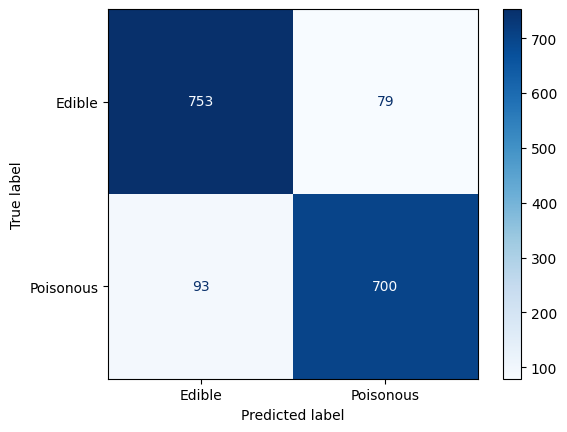

Best parameters found by Grid Search (Random Forest): {'classifier__bootstrap': True, 'classifier__max_depth': None, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Model name = Random Forest After
              precision    recall  f1-score   support

      Edible       0.89      0.91      0.90       832
   Poisonous       0.90      0.89      0.89       793

    accuracy                           0.90      1625
   macro avg       0.90      0.90      0.90      1625
weighted avg       0.90      0.90      0.90      1625



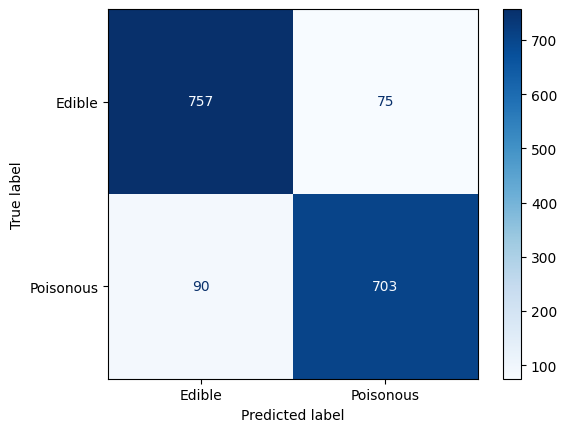

Cv score = [0.91039427 0.90952666 0.90161002 0.90161002 0.89155183]
 Mean score = 0.9029385582249982
 Std score = 0.006814372516660559

CV mean vs Test: 0.9029385582249982 vs 0.8937426210153483


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score,StratifiedKFold


pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

pipe_rf.fit(x_train, y_train)
confusion_model(pipe_rf, x_train, y_train, x_test, y_test, "Random Forest Before")

#am lasat un parametru pentru a rula codu mai repede ca deja am testat
param_grid_rf = {
    "classifier__n_estimators": [100],
    "classifier__max_depth": [None],
    "classifier__min_samples_split": [5],
    "classifier__min_samples_leaf": [1],
    "classifier__max_features": ["sqrt", "log2"],
    "classifier__bootstrap": [True],

}
scorer_rf = make_scorer(f1_score, pos_label="e")
cv_fold = StratifiedKFold(n_splits=5, shuffle = True, random_state = 42)


grid_search_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    cv = cv_fold,
    scoring=scorer_rf,
    n_jobs=-1,

)

grid_search_rf.fit(x_train, y_train)

print(f"Best parameters found by Grid Search (Random Forest): {grid_search_rf.best_params_}")

best_params_rf = grid_search_rf.best_params_

pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=best_params_rf['classifier__n_estimators'],
        max_depth=best_params_rf['classifier__max_depth'],
        min_samples_split=best_params_rf['classifier__min_samples_split'],
        min_samples_leaf=best_params_rf['classifier__min_samples_leaf'],
        bootstrap=best_params_rf['classifier__bootstrap'],
        max_features=best_params_rf["classifier__max_features"],
        random_state=42
    ))
])

confusion_model(pipeline_rf, x_train, y_train, x_test, y_test, "Random Forest After")


cv_scores_rf = cross_val_score(pipeline_rf,x,y,scoring = scorer_rf, cv = cv_fold)


print(f"Cv score = {cv_scores_rf}\n Mean score = {np.mean(cv_scores_rf)}\n Std score = {np.std(cv_scores_rf)}\n")
y_prec_rf = precision_score(y_test,y_pred,pos_label = 'e')
print("CV mean vs Test:", np.mean(cv_scores_rf), "vs", y_prec_rf)

###Random Forest roc curve for grid search

AUC: 0.9047


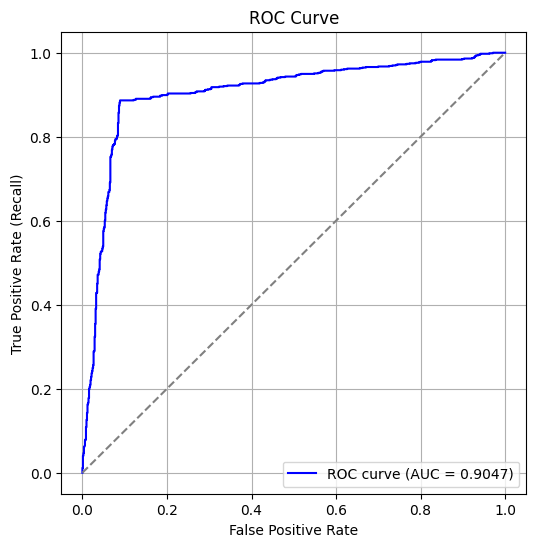

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_scores = pipeline_rf.predict_proba(x_test)[:, 1]

# Compute ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_scores,pos_label="p")

# Compute AUC
auc = roc_auc_score(y_test, y_scores)
print(f"AUC: {auc:.4f}")

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # diagonal line = random
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

###Support Vector Machine (SVM) with **RBF** kernel

Model name = SVM Before
              precision    recall  f1-score   support

      Edible       0.89      0.91      0.90       832
   Poisonous       0.90      0.89      0.89       793

    accuracy                           0.90      1625
   macro avg       0.90      0.90      0.90      1625
weighted avg       0.90      0.90      0.90      1625



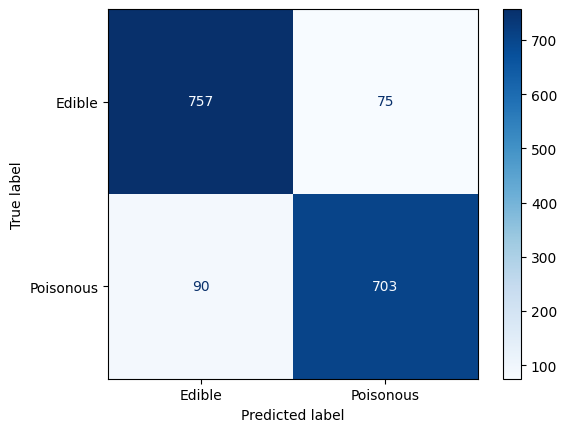

Best parameters found by Grid Search (SVM): {'classifier__C': 1, 'classifier__gamma': 0.1, 'classifier__kernel': 'rbf'}
Model name = SVM After
              precision    recall  f1-score   support

      Edible       0.89      0.91      0.90       832
   Poisonous       0.90      0.89      0.89       793

    accuracy                           0.90      1625
   macro avg       0.90      0.90      0.90      1625
weighted avg       0.90      0.90      0.90      1625



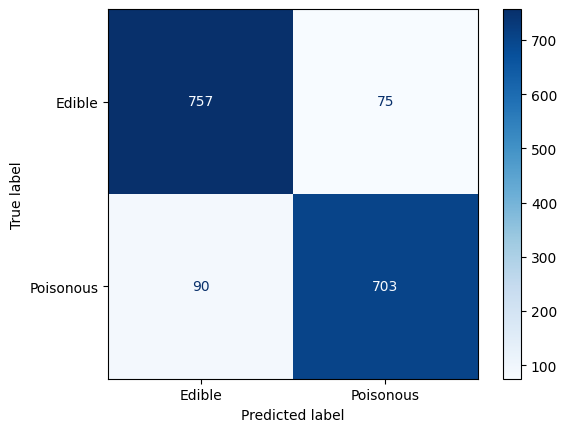

Cv score = [0.91039427 0.90952666 0.90161002 0.90161002 0.89155183]
 Mean score = 0.9029385582249982
 Std score = 0.006814372516660559

CV mean vs Test: 0.9029385582249982 vs 0.8937426210153483


In [ ]:
from sklearn.svm import SVC

pipeline_svm = Pipeline([
    ("preprocessor",preprocessor),
    ("classifier",SVC(random_state= 42))
])

pipeline_svm.fit(x_train,y_train)


param_grid_svm = {
    "classifier__C": [1], #am lasat un parametru pentru rularea mai rapida,dar am testat inainte
    "classifier__gamma": [0.1,"scale",],
    "classifier__kernel": ["rbf"]
}
confusion_model(pipeline_svm, x_train, y_train, x_test, y_test, "SVM Before")


scorer_vm = make_scorer(f1_score,pos_label = 'e')
cv_fold = StratifiedKFold(random_state = 42, shuffle = True, n_splits= 5)


grid_search_svm = GridSearchCV(pipeline_svm,param_grid = param_grid_svm,scoring = scorer_vm)
grid_search_svm.fit(x_train, y_train)

print(f"Best parameters found by Grid Search (SVM): {grid_search_svm.best_params_}")

best_params_svm = grid_search_svm.best_params_

pipeline_svm_final = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(
        C=best_params_svm["classifier__C"],
        gamma=best_params_svm["classifier__gamma"],
        kernel=best_params_svm["classifier__kernel"],
        probability = True
    ))
])

confusion_model(pipeline_svm_final, x_train, y_train, x_test, y_test, "SVM After")
cross_val_score_svm = cross_val_score(pipeline_svm_final,x,y,scoring = scorer_vm, cv = cv_fold)


print(f"Cv score = {cross_val_score_svm}\n Mean score = {np.mean(cross_val_score_svm)}\n Std score = {np.std(cross_val_score_svm)}\n")
y_prec_svm = precision_score(y_test,y_pred,pos_label = 'e')
print("CV mean vs Test:", np.mean(cross_val_score_svm), "vs", y_prec_svm)

###SVM Roc curve for Grid search

AUC: 0.8981


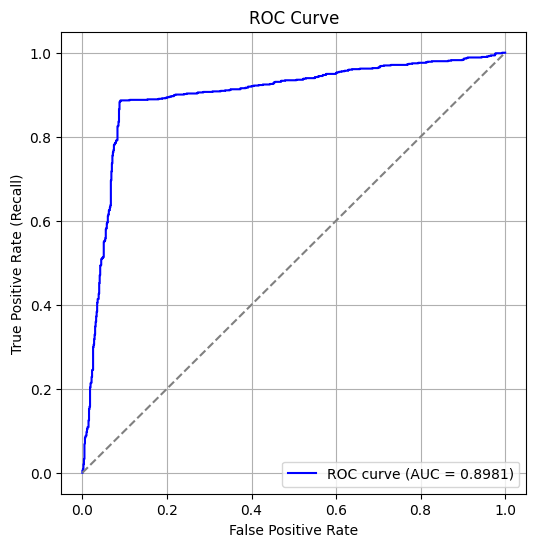

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_scores = pipeline_svm_final.predict_proba(x_test)[:, 1]

# Compute ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_scores,pos_label="p")

# Compute AUC
auc = roc_auc_score(y_test, y_scores)
print(f"AUC: {auc:.4f}")

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # diagonal line = random
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#Results table between cross score and gridsearch

In [ ]:
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'Mean CV Score': [
        np.mean(cross_val_score),
        np.mean(cv_scores_rf),
        np.mean(cross_val_score_svm)
    ],
    'Test Score': [y_prec, y_prec_rf, y_prec_svm]
}


results_df = pd.DataFrame(results)


results_df['Diff (Test - CV)'] = results_df['Test Score'] - results_df['Mean CV Score']

display(results_df)

,Model,Mean CV Score,Test Score,Diff (Test - CV)
0,Logistic Regression,0.902722,0.893743,-0.008980
1,Random Forest,0.902939,0.893743,-0.009196
2,SVM,0.902939,0.893743,-0.009196


The disadvantage of grid search is that if the param grid is poorly chosen then the model will have bad results

#Randomised Search

###Logistic Regression

Model name = Logistic Regression Before
              precision    recall  f1-score   support

      Edible       0.89      0.91      0.90       832
   Poisonous       0.90      0.89      0.89       793

    accuracy                           0.90      1625
   macro avg       0.90      0.90      0.90      1625
weighted avg       0.90      0.90      0.90      1625



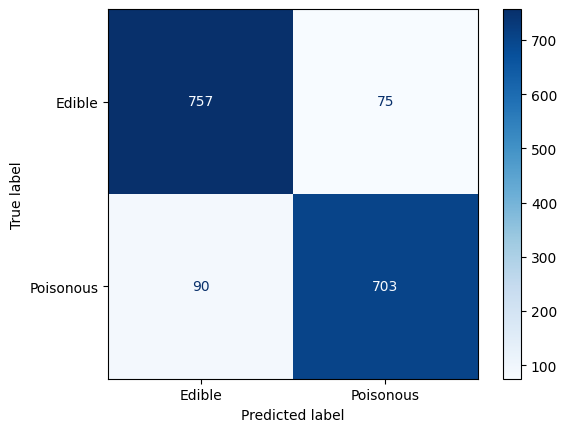

Best parameters found by Random Search: {'classifier__solver': 'liblinear', 'classifier__penalty': 'l2', 'classifier__max_iter': 1000, 'classifier__class_weight': 'balanced', 'classifier__C': np.float64(6.158482110660261)}
Model name = Logistic Regression After
              precision    recall  f1-score   support

      Edible       0.89      0.91      0.90       832
   Poisonous       0.90      0.88      0.89       793

    accuracy                           0.90      1625
   macro avg       0.90      0.90      0.90      1625
weighted avg       0.90      0.90      0.90      1625



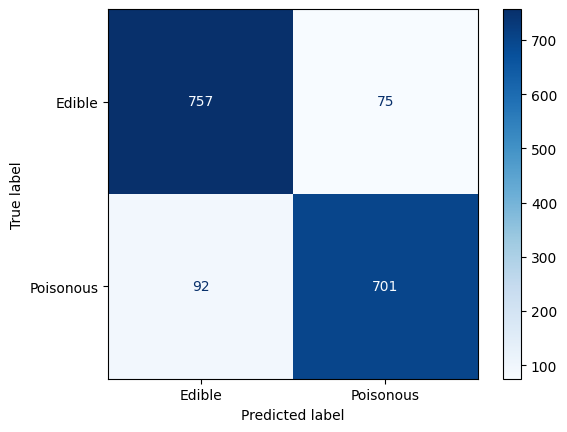

Cv score = [0.90985075 0.90952666 0.90107271 0.90161002 0.89155183]
 Mean score = 0.9027223919746985
 Std score = 0.006720891129743247

CV mean vs Test: 0.9027223919746985 vs 0.8937426210153483


In [ ]:
from sklearn.model_selection import RandomizedSearchCV



pipe = Pipeline([
    ("preprocessor",preprocessor),
    ("classifier",LogisticRegression(random_state = 42))
])


pipe.fit(x_train, y_train)
confusion_model(pipe,x_train,y_train,x_test,y_test,"Logistic Regression Before")


param_distributions = {
    "classifier__penalty": ["l2"],  #am lasat un parametru pentru a rula codu mai repede ca deja am testat
    "classifier__C": np.logspace(-3, 3, 20),
    "classifier__solver": ["liblinear", "saga"],
    "classifier__max_iter": [1000,5000,10000],
    "classifier__class_weight": [None, "balanced"]
}
scorer = make_scorer(f1_score, pos_label="e")
cv_fold = StratifiedKFold(random_state = 42, shuffle = True, n_splits= 5)



random_search = RandomizedSearchCV(estimator = pipe, param_distributions = param_distributions,  n_iter = 10 , cv = cv_fold, n_jobs = -1, scoring = scorer)
random_search.fit(x_train,y_train)


print(f"Best parameters found by Random Search: {random_search.best_params_}")

best_params = random_search.best_params_
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        penalty = best_params['classifier__penalty'],
        C = best_params['classifier__C'],
        solver = best_params['classifier__solver'],
        max_iter = best_params['classifier__max_iter'],
        class_weight = best_params['classifier__class_weight'],
        random_state = 42
    ))
])

confusion_model(pipeline_lr,x_train,y_train,x_test,y_test,"Logistic Regression After")

cross_val_score_logistic = cross_val_score(pipeline_lr,x,y,scoring = scorer, cv = cv_fold)


print(f"Cv score = {cross_val_score_logistic}\n Mean score = {np.mean(cross_val_score_logistic)}\n Std score = {np.std(cross_val_score_logistic)}\n")
y_prec = precision_score(y_test,y_pred,pos_label = 'e')
print("CV mean vs Test:", np.mean(cross_val_score_logistic), "vs", y_prec)





###Roc curve Logistic Regression for Randomised search

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_scores = pipeline_lr.predict_proba(x_test)[:, 1]

# Compute ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_scores,pos_label="e")

# Compute AUC
auc = roc_auc_score(y_test, y_scores)
print(f"AUC: {auc:.4f}")

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # diagonal line = random
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

###Random Forest

Model name = Random Forest Before
              precision    recall  f1-score   support

      Edible       0.89      0.91      0.90       832
   Poisonous       0.90      0.88      0.89       793

    accuracy                           0.89      1625
   macro avg       0.89      0.89      0.89      1625
weighted avg       0.89      0.89      0.89      1625



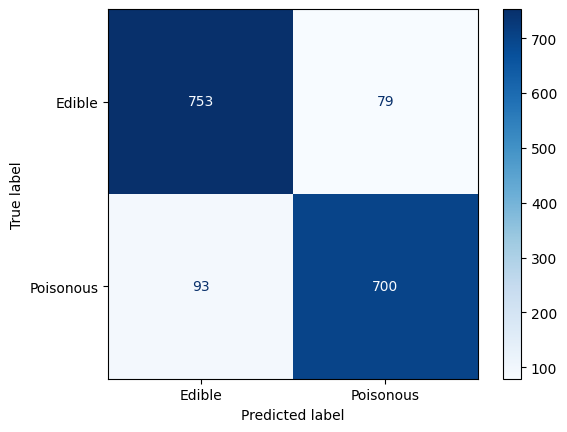

Best parameters found by Random Search (Random Forest): {'classifier__n_estimators': 800, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'log2', 'classifier__max_depth': None, 'classifier__bootstrap': True}
Model name = Random Forest After
              precision    recall  f1-score   support

      Edible       0.89      0.91      0.90       832
   Poisonous       0.90      0.89      0.89       793

    accuracy                           0.90      1625
   macro avg       0.90      0.90      0.90      1625
weighted avg       0.90      0.90      0.90      1625



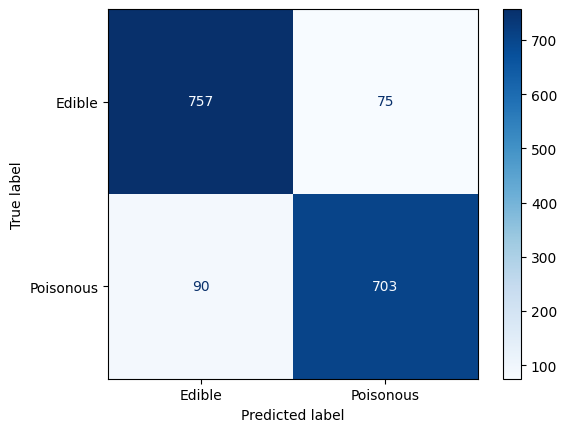

Cv score = [0.91039427 0.90952666 0.90161002 0.90161002 0.89155183]
 Mean score = 0.9029385582249982
 Std score = 0.006814372516660559

CV mean vs Test: 0.9029385582249982 vs 0.8937426210153483


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, RandomizedSearchCV

pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

pipe_rf.fit(x_train, y_train)
confusion_model(pipe_rf, x_train, y_train, x_test, y_test, "Random Forest Before")

param_distributions_rf = {
    "classifier__n_estimators": [100, 200, 300, 500, 800, 1000],
    "classifier__max_depth": [None, 5, 10, 20, 30, 50],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 4, 8],
    "classifier__max_features": ["sqrt", "log2", None, 0.5],
    "classifier__bootstrap": [True, False]
}

scorer_rf = make_scorer(f1_score, pos_label="e")
cv_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_rf = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_distributions_rf,
    n_iter=10,
    cv=cv_fold,
    scoring=scorer_rf,
    n_jobs=-1,
    random_state=42
)

random_search_rf.fit(x_train, y_train)
print(f"Best parameters found by Random Search (Random Forest): {random_search_rf.best_params_}")

best_params_rf = random_search_rf.best_params_

pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=best_params_rf['classifier__n_estimators'],
        max_depth=best_params_rf['classifier__max_depth'],
        min_samples_split=best_params_rf['classifier__min_samples_split'],
        min_samples_leaf=best_params_rf['classifier__min_samples_leaf'],
        bootstrap=best_params_rf['classifier__bootstrap'],
        max_features=best_params_rf['classifier__max_features'],
        random_state=42
    ))
])

confusion_model(pipeline_rf, x_train, y_train, x_test, y_test, "Random Forest After")

cv_scores_rf = cross_val_score(pipeline_rf, x, y, scoring=scorer_rf, cv=cv_fold)

print(f"Cv score = {cv_scores_rf}\n Mean score = {np.mean(cv_scores_rf)}\n Std score = {np.std(cv_scores_rf)}\n")
y_prec_rf = precision_score(y_test, y_pred, pos_label='e')
print("CV mean vs Test:", np.mean(cv_scores_rf), "vs", y_prec_rf)


###Random Forest Roc curve  for Randomised search

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_scores = pipeline_rf.predict_proba(x_test)[:, 1]

# Compute ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_scores,pos_label="p")

# Compute AUC
auc = roc_auc_score(y_test, y_scores)
print(f"AUC: {auc:.4f}")

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # diagonal line = random
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

###Support vector machine (SVM) with RBF kernel

Model name = SVM Before
              precision    recall  f1-score   support

      Edible       0.89      0.91      0.90       832
   Poisonous       0.90      0.89      0.89       793

    accuracy                           0.90      1625
   macro avg       0.90      0.90      0.90      1625
weighted avg       0.90      0.90      0.90      1625



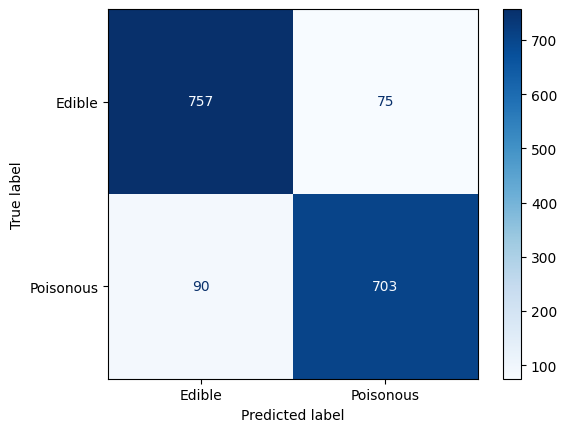

Best parameters found by Random Search (SVM): {'classifier__kernel': 'rbf', 'classifier__gamma': 0.1, 'classifier__C': 1}
Model name = SVM After
              precision    recall  f1-score   support

      Edible       0.89      0.91      0.90       832
   Poisonous       0.90      0.89      0.89       793

    accuracy                           0.90      1625
   macro avg       0.90      0.90      0.90      1625
weighted avg       0.90      0.90      0.90      1625



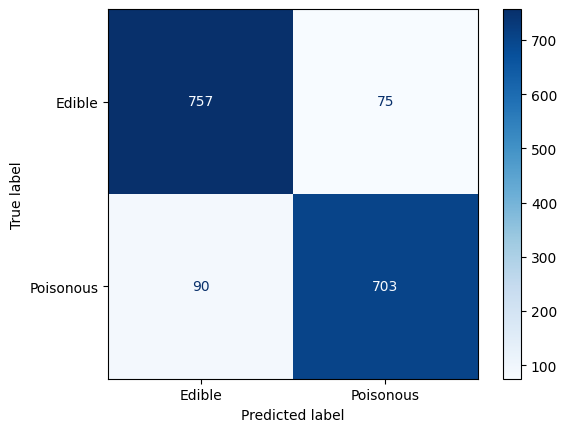

Cv score = [0.91039427 0.90952666 0.90161002 0.90161002 0.89155183]
 Mean score = 0.9029385582249982
 Std score = 0.006814372516660559

CV mean vs Test: 0.9029385582249982 vs 0.8937426210153483


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score

pipeline_svm = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(random_state=42))
])

pipeline_svm.fit(x_train, y_train)
confusion_model(pipeline_svm, x_train, y_train, x_test, y_test, "SVM Before")

param_distributions_svm = {
    "classifier__C": [0.1, 1, 10, 100],
    "classifier__gamma": [0.001, 0.01, 0.1, 1, "scale"],
    "classifier__kernel": ["rbf"]
}

scorer_vm = make_scorer(f1_score, pos_label="e")
cv_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_svm = RandomizedSearchCV(
    estimator=pipeline_svm,
    param_distributions=param_distributions_svm,
    n_iter=20,
    scoring = scorer_vm,
    cv=cv_fold,
    n_jobs=-1,
    random_state=42
)

random_search_svm.fit(x_train, y_train)
print(f"Best parameters found by Random Search (SVM): {random_search_svm.best_params_}")

best_params_svm = random_search_svm.best_params_

pipeline_svm_final = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(
        C=best_params_svm["classifier__C"],
        gamma=best_params_svm["classifier__gamma"],
        kernel=best_params_svm["classifier__kernel"],
        random_state=42,
        probavility = True
    ))
])

confusion_model(pipeline_svm_final, x_train, y_train, x_test, y_test, "SVM After")

cross_val_score_svm = cross_val_score(pipeline_svm_final, x, y, scoring=scorer_vm, cv=cv_fold)

print(f"Cv score = {cross_val_score_svm}\n Mean score = {np.mean(cross_val_score_svm)}\n Std score = {np.std(cross_val_score_svm)}\n")

y_pred = pipeline_svm_final.fit(x_train, y_train).predict(x_test)
y_prec_svm = precision_score(y_test, y_pred, pos_label='e')
print("CV mean vs Test:", np.mean(cross_val_score_svm), "vs", y_prec_svm)


###Svm Roc curve  for Randomised search

AUC: 0.8981


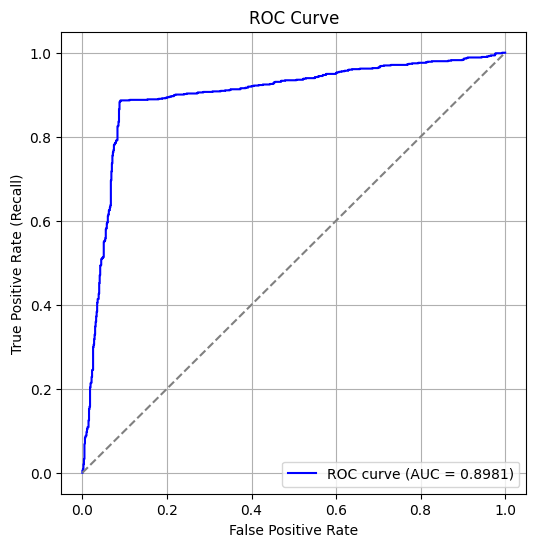

In [ ]:

y_scores = pipeline_svm_final.predict_proba(x_test)[:, 1]

# Compute ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_scores,pos_label="p")

# Compute AUC
auc = roc_auc_score(y_test, y_scores)
print(f"AUC: {auc:.4f}")

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # diagonal line = random
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

###Results table for randomised search


In [ ]:
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'Mean CV Score': [
        np.mean(cross_val_score_logistic),
        np.mean(cv_scores_rf),
        np.mean(cross_val_score_svm)
    ],
    'Test Score': [y_prec, y_prec_rf, y_prec_svm]
}


results_df = pd.DataFrame(results)


results_df['Diff (Test - CV)'] = results_df['Test Score'] - results_df['Mean CV Score']

display(results_df)


,Model,Mean CV Score,Test Score,Diff (Test - CV)
0,Logistic Regression,0.902722,0.893743,-0.008980
1,Random Forest,0.902939,0.893743,-0.009196
2,SVM,0.902939,0.893743,-0.009196


#Conclusions

*  The model shows stable CV results (0.0 - 0.01), but its test score drops to 0.1, indicating slight overfitting or a distribution gap between train and test data.
*  RandomizedSearchCV and GridSearchCV didn’t bring much improvement, likely
because of label noise. I also ran into issues with cross-validation scores varying a lot across the parameter grid, which made it harder to find stable settings
*  The ROC curve revealed that the model performed well only when the class labels were effectively inverted.

When treating the intended positive class as positive, the ROC curve fell below the random diagonal, indicating that the model was predicting inversely.

This suggests that the model scoring is more aligned with the negative class, and the AUC improved significantly after inverting the labels or scores.